In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('datasets/CIPLA.csv')

In [2]:
#importing required libraries
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

In [3]:
#creating dataframe
data = df.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(df)),columns=['Date', 'Close'])

In [5]:
data

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,CIPLA,EQ,1349.40,1410.00,1457.35,1380.05,1457.35,1457.35,1441.36,21060,3.035496e+12,NaN,NaN,NaN
1,2000-01-04,CIPLA,EQ,1457.35,1537.00,1537.00,1430.00,1466.05,1465.25,1460.43,30215,4.412698e+12,NaN,NaN,NaN
2,2000-01-05,CIPLA,EQ,1465.25,1474.00,1474.00,1365.00,1441.00,1435.05,1428.11,33799,4.826872e+12,NaN,NaN,NaN
3,2000-01-06,CIPLA,EQ,1435.05,1434.00,1435.00,1349.00,1365.00,1355.85,1390.55,33083,4.600356e+12,NaN,NaN,NaN
4,2000-01-07,CIPLA,EQ,1355.85,1370.00,1389.90,1247.40,1247.40,1247.55,1267.49,66536,8.433351e+12,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5282,2021-03-24,CIPLA,EQ,776.10,777.80,798.70,772.65,791.00,792.95,789.82,6904173,5.453025e+14,118668.0,1808708.0,0.2620
5283,2021-03-25,CIPLA,EQ,792.95,796.90,802.30,783.30,788.65,787.25,791.95,5292130,4.191119e+14,105987.0,1535589.0,0.2902
5284,2021-03-26,CIPLA,EQ,787.25,791.00,799.00,781.25,790.00,787.45,789.54,2934548,2.316946e+14,59596.0,987183.0,0.3364
5285,2021-03-30,CIPLA,EQ,787.45,790.25,815.90,790.25,810.00,812.20,808.03,4453933,3.598929e+14,125974.0,1578325.0,0.3544


In [6]:
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data['Close'][i] = data['Close'][i]

In [7]:
#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

In [9]:
new_data

,Close
Date,
2000-01-03,1457.35
2000-01-04,1465.25
2000-01-05,1435.05
2000-01-06,1355.85
2000-01-07,1247.55
...,...
2021-03-24,792.95
2021-03-25,787.25
2021-03-26,787.45


In [10]:
#creating train and test sets
dataset = new_data.values

train = dataset[0:3965,:]
valid = dataset[3965:,:]

In [125]:
dataset

array([[1457.35],
       [1465.25],
       [1435.05],
       ...,
       [787.45],
       [812.2],
       [815.1]], dtype=object)

In [11]:
#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

In [12]:
x_train, y_train = [], []
for i in range(60,len(train)):
    x_train.append(scaled_data[i-60:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [13]:
x_train

array([[[0.99394706],
        [1.        ],
        [0.9768609 ],
        ...,
        [0.69287055],
        [0.66467456],
        [0.68061142]],

       [[1.        ],
        [0.9768609 ],
        [0.91617822],
        ...,
        [0.66467456],
        [0.68061142],
        [0.68245029]],

       [[0.9768609 ],
        [0.91617822],
        [0.83319925],
        ...,
        [0.68061142],
        [0.68245029],
        [0.74569973]],

       ...,

       [[0.37183466],
        [0.3657434 ],
        [0.38374899],
        ...,
        [0.36436425],
        [0.37294564],
        [0.36880818]],

       [[0.3657434 ],
        [0.38374899],
        [0.38290618],
        ...,
        [0.37294564],
        [0.36880818],
        [0.36562847]],

       [[0.38374899],
        [0.38290618],
        [0.39999234],
        ...,
        [0.36880818],
        [0.36562847],
        [0.36352143]]])

In [14]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=1, batch_size=1, verbose=2)

3905/3905 - 84s - loss: 0.0014 - 84s/epoch - 21ms/step


In [15]:
#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)

In [16]:
X_test = []
for i in range(60,inputs.shape[0]):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)

In [17]:
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

42/42 [==============================] - 1s 10ms/step


In [18]:
rms=np.sqrt(np.mean(np.power((valid-closing_price),2)))
rms

42.436663211881104

In [19]:
#for plotting
train = new_data[:3965]
valid = new_data[3965:]
valid['Predictions'] = closing_price

C:\Users\Swapnil.wagh\AppData\Local\Temp\ipykernel_24236\42541526.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = closing_price


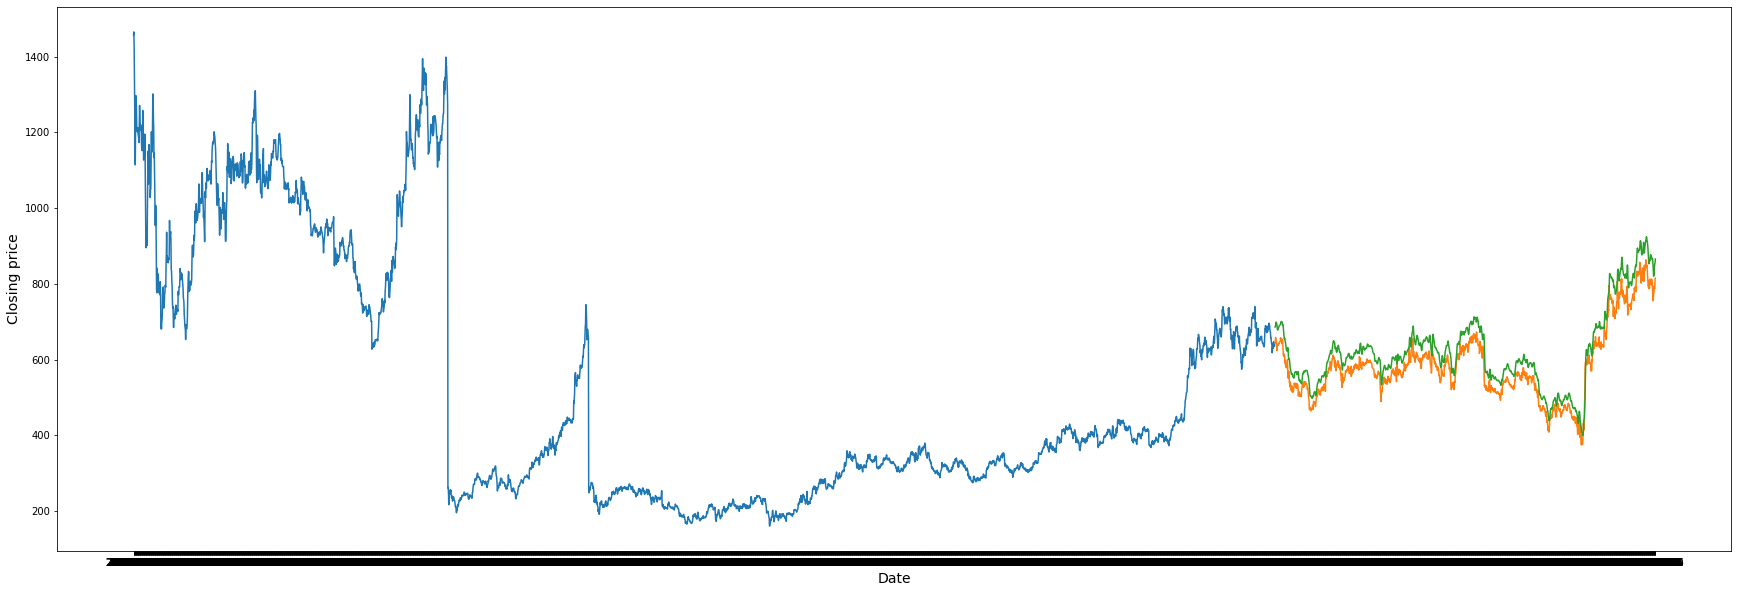

In [26]:

#setting index
plt.figure(figsize=(30,10))

plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])
plt.xlabel('Date',fontsize=14)
plt.ylabel('Closing price',fontsize=14)
plt.show()

# #setting index
# plt.figure(figsize=(30,10))

# plt.plot(train1,train2)
# plt.plot(valid1,valid2)
# plt.plot(valid1,valid3)
# plt.xlabel('Date')
# plt.ylabel('Closing price')
# plt.show()

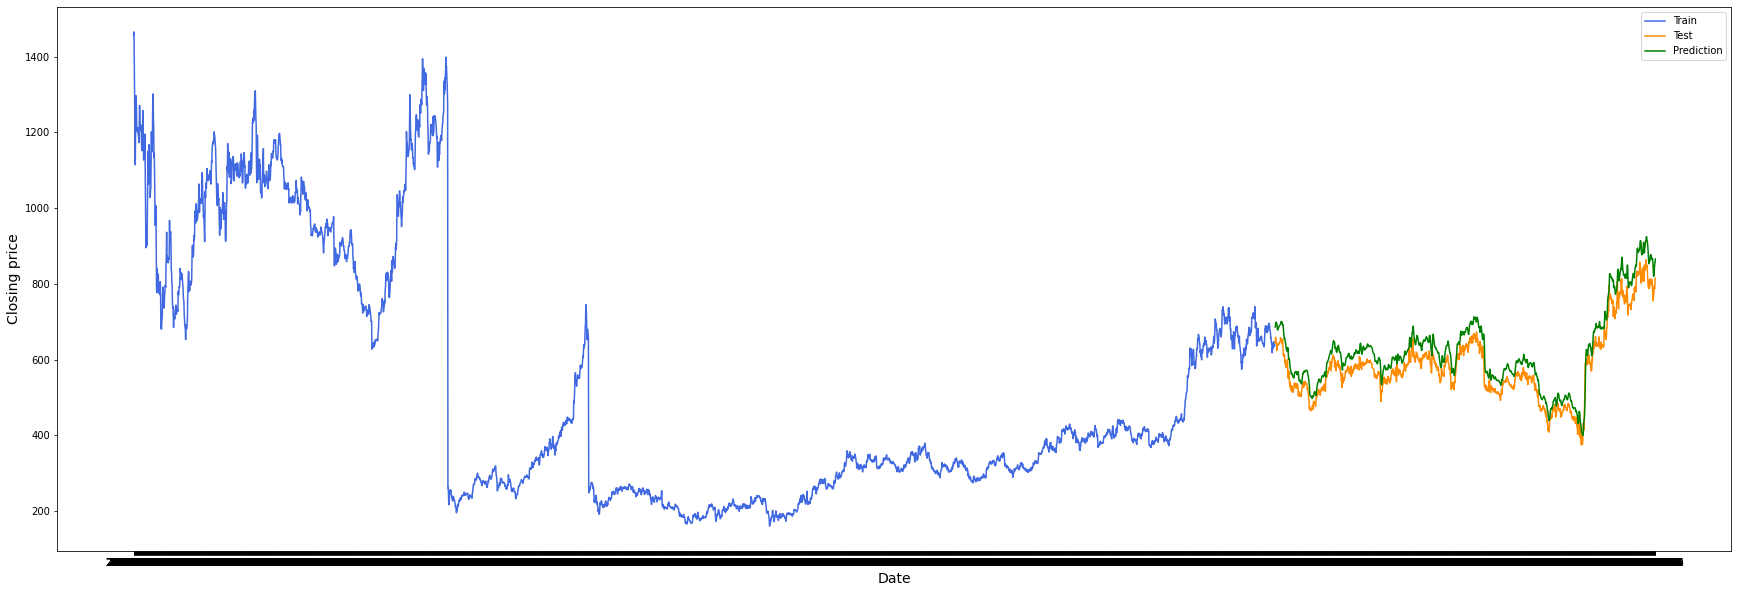

In [28]:
plt.figure(figsize=(30,10))

plt.plot(train['Close'],label='Train',color="royalblue")
plt.plot(valid['Close'],label='Test',color="darkorange")
plt.plot(valid['Predictions'],label='Prediction',color="green")
plt.xlabel('Date',fontsize=14)
plt.ylabel('Closing price',fontsize=14)
plt.legend(loc='best')
plt.show()